In [41]:
import numpy as np # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import seaborn as sb # type: ignore
from sklearn.ensemble import IsolationForest # type: ignore
from scipy.stats import norm # type: ignore
from scipy.stats import multivariate_normal as mvn # type: ignore
from sklearn.decomposition import PCA # type: ignore
from sklearn.mixture import GaussianMixture # type: ignore
import plotly.express as px # type: ignore
from plotly import graph_objects as go # type: ignore

### __load data__

In [42]:
data = pd.read_csv('elb_request_count_8c0756.csv')
data

,timestamp,value
0,2014-04-10 00:04:00,94.0
1,2014-04-10 00:09:00,56.0
2,2014-04-10 00:14:00,187.0
3,2014-04-10 00:19:00,95.0
4,2014-04-10 00:24:00,51.0
...,...,...
4027,2014-04-24 00:19:00,32.0
4028,2014-04-24 00:24:00,57.0
4029,2014-04-24 00:29:00,10.0
4030,2014-04-24 00:34:00,18.0


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  4032 non-null   object 
 1   value      4032 non-null   float64
dtypes: float64(1), object(1)
memory usage: 63.1+ KB


In [44]:
data.describe()

,value
count,4032.000000
mean,61.837054
std,56.664703
min,1.000000
25%,15.000000
50%,48.000000
75%,89.000000
max,656.000000


### __preprocessing__

In [45]:
data['timestamp'] = pd.to_datetime(data['timestamp'])
data.dtypes

timestamp    datetime64[ns]
value               float64
dtype: object

In [46]:
# sb.set_style('darkgrid')
# plt.figure(figsize=(40, 10))
# sb.lineplot(data, x='timestamp', y='value')
px.line(data, x='timestamp', y='value', width=1600, height=400)

In [47]:
data_copy = data.copy()
# make columns that shows 5 preview values
for i  in range(5):
    data_copy['prev_' + str(i + 1)] = data_copy['value'].shift(i + 1)
data_copy

,timestamp,value,prev_1,prev_2,prev_3,prev_4,prev_5
0,2014-04-10 00:04:00,94.0,NaN,NaN,NaN,NaN,NaN
1,2014-04-10 00:09:00,56.0,94.0,NaN,NaN,NaN,NaN
2,2014-04-10 00:14:00,187.0,56.0,94.0,NaN,NaN,NaN
3,2014-04-10 00:19:00,95.0,187.0,56.0,94.0,NaN,NaN
4,2014-04-10 00:24:00,51.0,95.0,187.0,56.0,94.0,NaN
...,...,...,...,...,...,...,...
4027,2014-04-24 00:19:00,32.0,4.0,12.0,29.0,182.0,13.0
4028,2014-04-24 00:24:00,57.0,32.0,4.0,12.0,29.0,182.0
4029,2014-04-24 00:29:00,10.0,57.0,32.0,4.0,12.0,29.0
4030,2014-04-24 00:34:00,18.0,10.0,57.0,32.0,4.0,12.0


In [48]:
data_copy.dropna(inplace=True)
data_copy

,timestamp,value,prev_1,prev_2,prev_3,prev_4,prev_5
5,2014-04-10 00:29:00,10.0,51.0,95.0,187.0,56.0,94.0
6,2014-04-10 00:34:00,49.0,10.0,51.0,95.0,187.0,56.0
7,2014-04-10 00:39:00,79.0,49.0,10.0,51.0,95.0,187.0
8,2014-04-10 00:44:00,24.0,79.0,49.0,10.0,51.0,95.0
9,2014-04-10 00:49:00,73.0,24.0,79.0,49.0,10.0,51.0
...,...,...,...,...,...,...,...
4027,2014-04-24 00:19:00,32.0,4.0,12.0,29.0,182.0,13.0
4028,2014-04-24 00:24:00,57.0,32.0,4.0,12.0,29.0,182.0
4029,2014-04-24 00:29:00,10.0,57.0,32.0,4.0,12.0,29.0
4030,2014-04-24 00:34:00,18.0,10.0,57.0,32.0,4.0,12.0


In [49]:
X = data_copy[['value'] + ['prev_'+str(i+1) for i in range(5)]].values

### __isolation forest__

In [50]:
model = IsolationForest(contamination=0.03)
# model.fit_predict(X)
labels = model.fit_predict(X)
labels


array([1, 1, 1, ..., 1, 1, 1])

In [51]:
data_copy['anomaly'] = labels
data_copy

,timestamp,value,prev_1,prev_2,prev_3,prev_4,prev_5,anomaly
5,2014-04-10 00:29:00,10.0,51.0,95.0,187.0,56.0,94.0,1
6,2014-04-10 00:34:00,49.0,10.0,51.0,95.0,187.0,56.0,1
7,2014-04-10 00:39:00,79.0,49.0,10.0,51.0,95.0,187.0,1
8,2014-04-10 00:44:00,24.0,79.0,49.0,10.0,51.0,95.0,1
9,2014-04-10 00:49:00,73.0,24.0,79.0,49.0,10.0,51.0,1
...,...,...,...,...,...,...,...,...
4027,2014-04-24 00:19:00,32.0,4.0,12.0,29.0,182.0,13.0,1
4028,2014-04-24 00:24:00,57.0,32.0,4.0,12.0,29.0,182.0,1
4029,2014-04-24 00:29:00,10.0,57.0,32.0,4.0,12.0,29.0,1
4030,2014-04-24 00:34:00,18.0,10.0,57.0,32.0,4.0,12.0,1


In [52]:
# sb.set_style('darkgrid')
# plt.figure(figsize=(40, 10))
# sb.lineplot(data_copy, x='timestamp', y='value', label='value')
# sb.scatterplot(data=data_copy[(data_copy['anomaly'] == -1)], x='timestamp', y='value', color='red', s=70, label='anomlay')
# plt.legend()

fig1 = px.line(data_copy, x='timestamp', y='value') # values
fig2 = px.scatter(data_copy[(data_copy['anomaly'] == -1)], x='timestamp', y='value', color='anomaly') # anomalies

fig3 = go.Figure(data=fig1.data + fig2.data); fig3.update_layout(coloraxis_showscale=False)
fig3.show()

In [53]:
# sb.histplot(data_copy, x='anomaly')
px.histogram(data_copy, x='anomaly',nbins=10, width=800, color='anomaly')

### __density based__

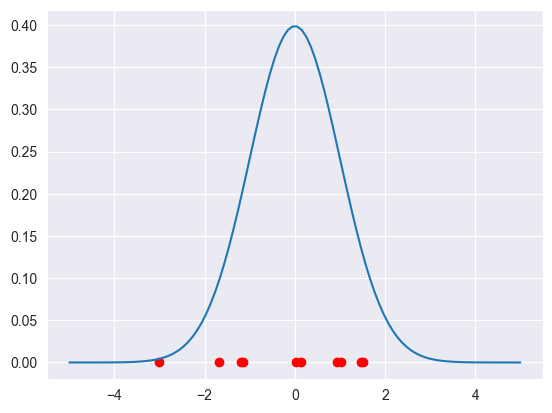

In [54]:
t = np.linspace(-5, 5, 100)
plt.plot(t, norm.pdf(t))
r = norm.rvs(size=10)
plt.scatter(r, np.zeros_like(r), color='r')

In [55]:
loc = X.mean(axis=0)
cov_data = np.cov(X.T)
log_likelihood = mvn.logpdf(X, mean=loc, cov=cov_data)

In [56]:
data_copy['log_likelihood'] = log_likelihood

<Axes: xlabel='timestamp', ylabel='value'>

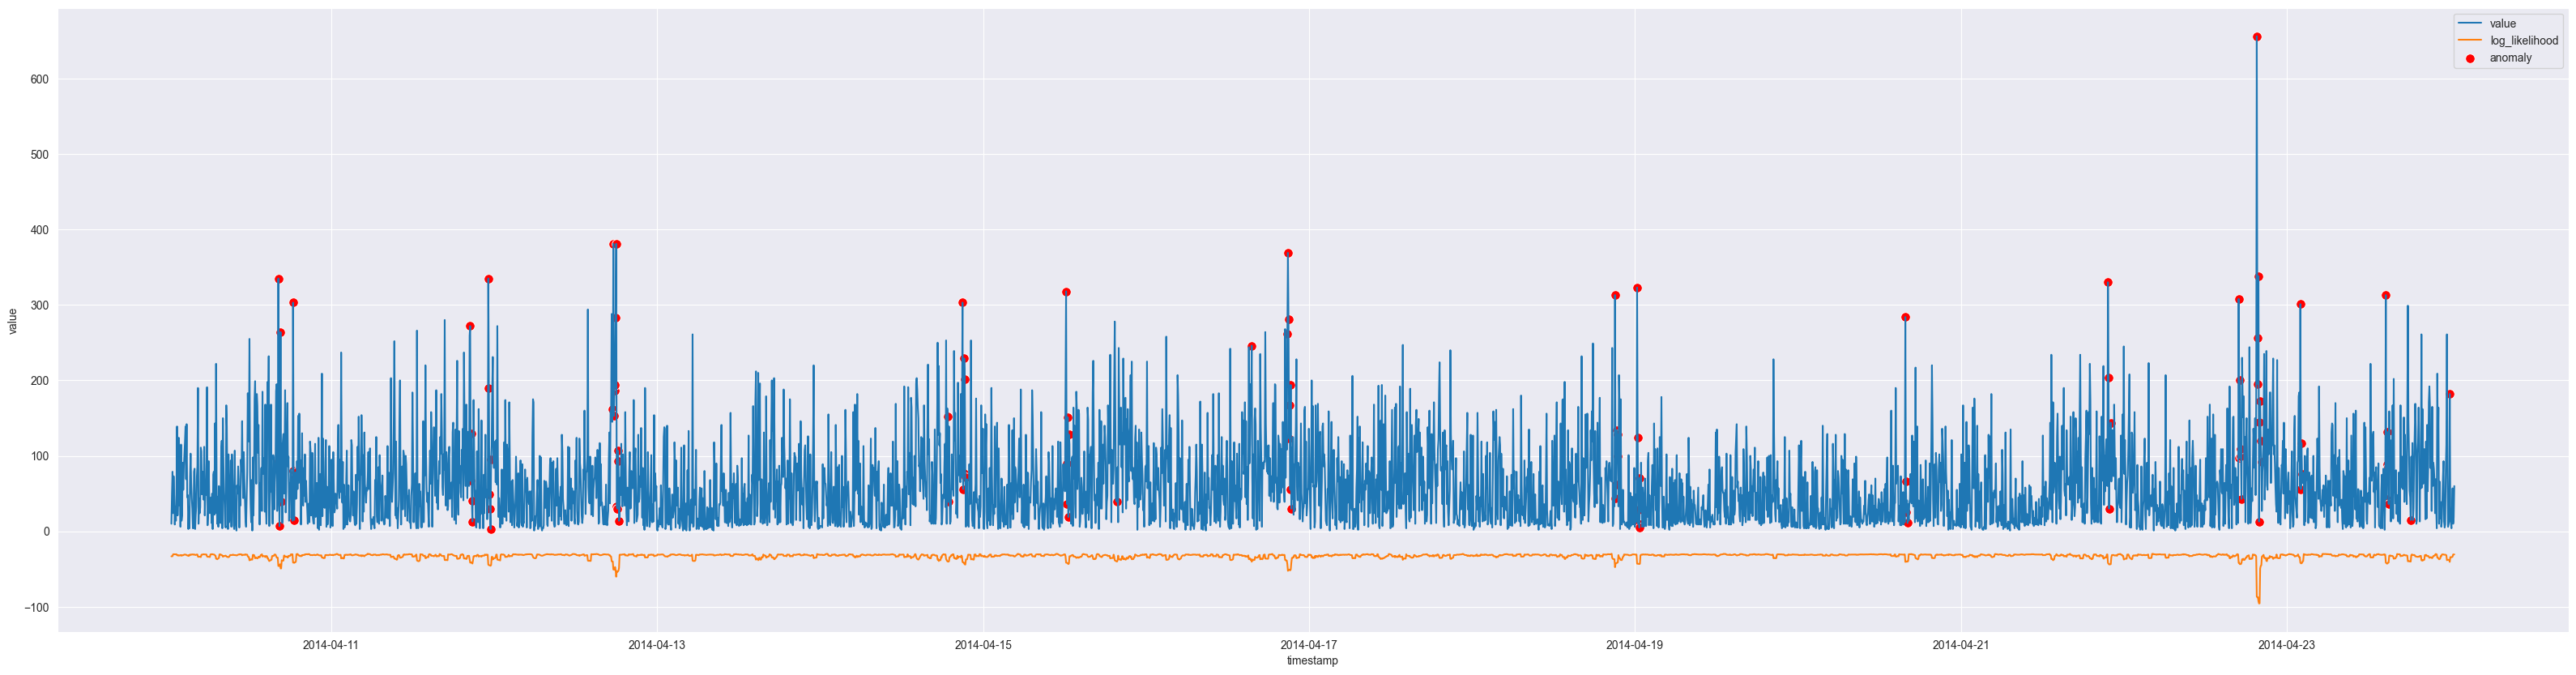

In [57]:
plt.figure(figsize=(40, 10))
sb.lineplot(data_copy, x='timestamp', y='value', label='value')
sb.lineplot(data_copy, x='timestamp', y='log_likelihood', label='log_likelihood')
sb.scatterplot(data=data_copy[(data_copy['log_likelihood'] < -40)], x='timestamp', y='value', color='red', label='anomaly', s=70)

In [58]:
pca = PCA(n_components=2).fit_transform(X)

In [59]:
data_copy[['p1', 'p2']] = pca
# sb.scatterplot(data_copy, x='p1', y='p2', hue='anomaly', palette='coolwarm')
px.scatter(data_copy, x='p1', y='p2', color='anomaly')

In [60]:
# sb.scatterplot(data_copy, x='p1', y='p2', hue='log_likelihood', palette='coolwarm')
px.scatter(data_copy, x='p1', y='p2', color='log_likelihood', color_continuous_scale=px.colors.sequential.algae_r)

In [61]:
data_copy['mean'] = data_copy['value'].rolling(10).mean()
data_copy['seasonality'] = data_copy['value'] - data_copy['mean']

<Axes: xlabel='timestamp', ylabel='value'>

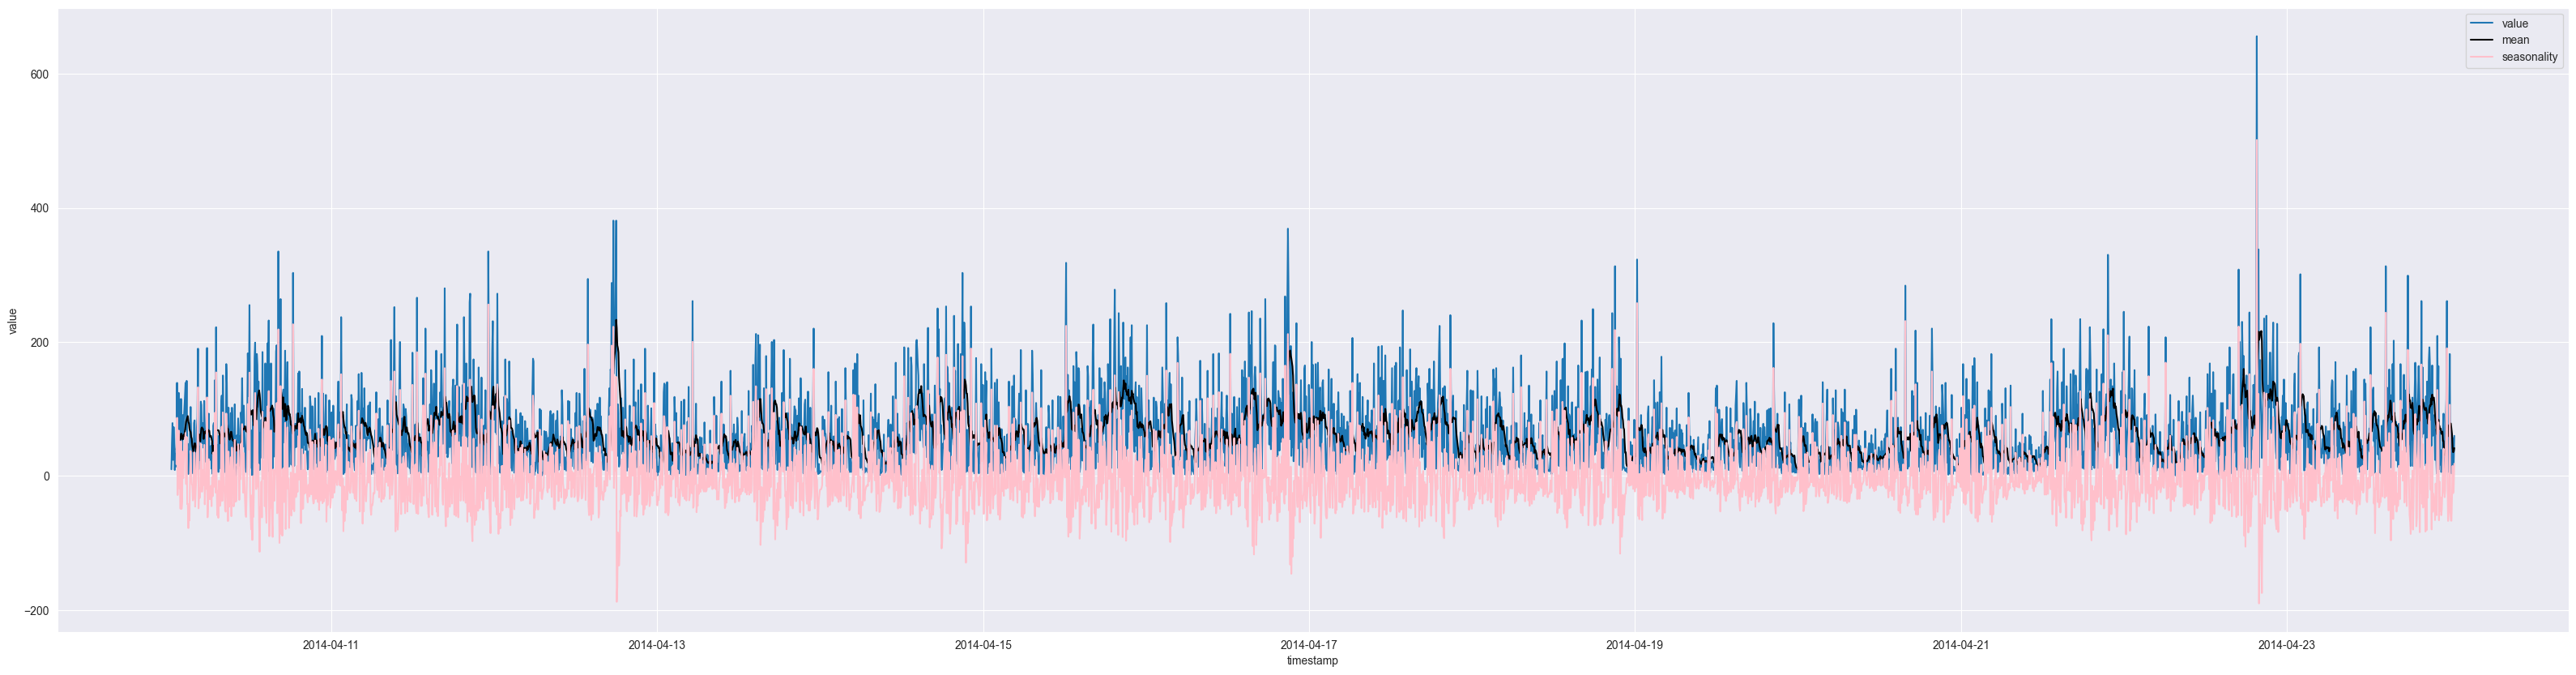

In [62]:
plt.figure(figsize=(40,10))
sb.lineplot(data_copy, x='timestamp', y='value', label='value')
sb.lineplot(data_copy, x='timestamp', y='mean', color='black', label='mean')
sb.lineplot(data_copy, x='timestamp', y='seasonality', color='pink', label='seasonality')

### __guassian distribution__

In [63]:
# using gaussian 
model_2 = GaussianMixture(n_components=2, covariance_type="full", random_state=24)
model_2.fit(data_copy[["value"]])

GaussianMixture(n_components=2, random_state=24)

In [64]:
# probability of vlues
data_copy["probability"] = model_2.score_samples(data_copy[["value"]])

In [65]:
# detect anomalies and not anomalies by thresholding(15%) the probabilities
threshold = np.percentile(data_copy["probability"], q=0.15)
data_copy["is_anomaly"], data_copy['is_not_anomaly'] = data_copy["probability"] < threshold, data_copy["probability"] >= threshold

In [66]:
# anomalies
data_copy[data_copy["is_anomaly"]]

,timestamp,value,prev_1,prev_2,prev_3,prev_4,prev_5,anomaly,log_likelihood,p1,p2,mean,seasonality,probability,is_anomaly,is_not_anomaly
193,2014-04-10 16:14:00,335.0,48.0,27.0,195.0,186.0,83.0,-1,-45.897683,200.910812,-1.279429,116.3,218.7,-12.473326,True,False
564,2014-04-11 23:09:00,335.0,31.0,16.0,55.0,45.0,128.0,1,-44.045512,88.643060,72.090089,79.1,255.9,-12.473326,True,False
785,2014-04-12 17:34:00,381.0,162.0,145.0,288.0,156.0,159.0,-1,-50.615333,371.619877,66.598034,158.3,222.7,-15.434840,True,False
790,2014-04-12 17:59:00,381.0,283.0,194.0,187.0,153.0,381.0,-1,-60.147687,484.718533,69.176679,233.0,148.0,-15.434840,True,False
1973,2014-04-16 20:54:00,369.0,262.0,108.0,169.0,71.0,268.0,-1,-52.304852,349.751997,129.024453,157.2,211.8,-14.607687,True,False
3682,2014-04-22 19:34:00,656.0,175.0,48.0,150.0,84.0,116.0,-1,-86.478961,337.555929,254.686858,154.8,501.2,-44.949446,True,False
3685,2014-04-22 19:49:00,338.0,195.0,256.0,656.0,175.0,48.0,-1,-92.792283,535.165456,47.487105,215.4,122.6,-12.649210,True,False


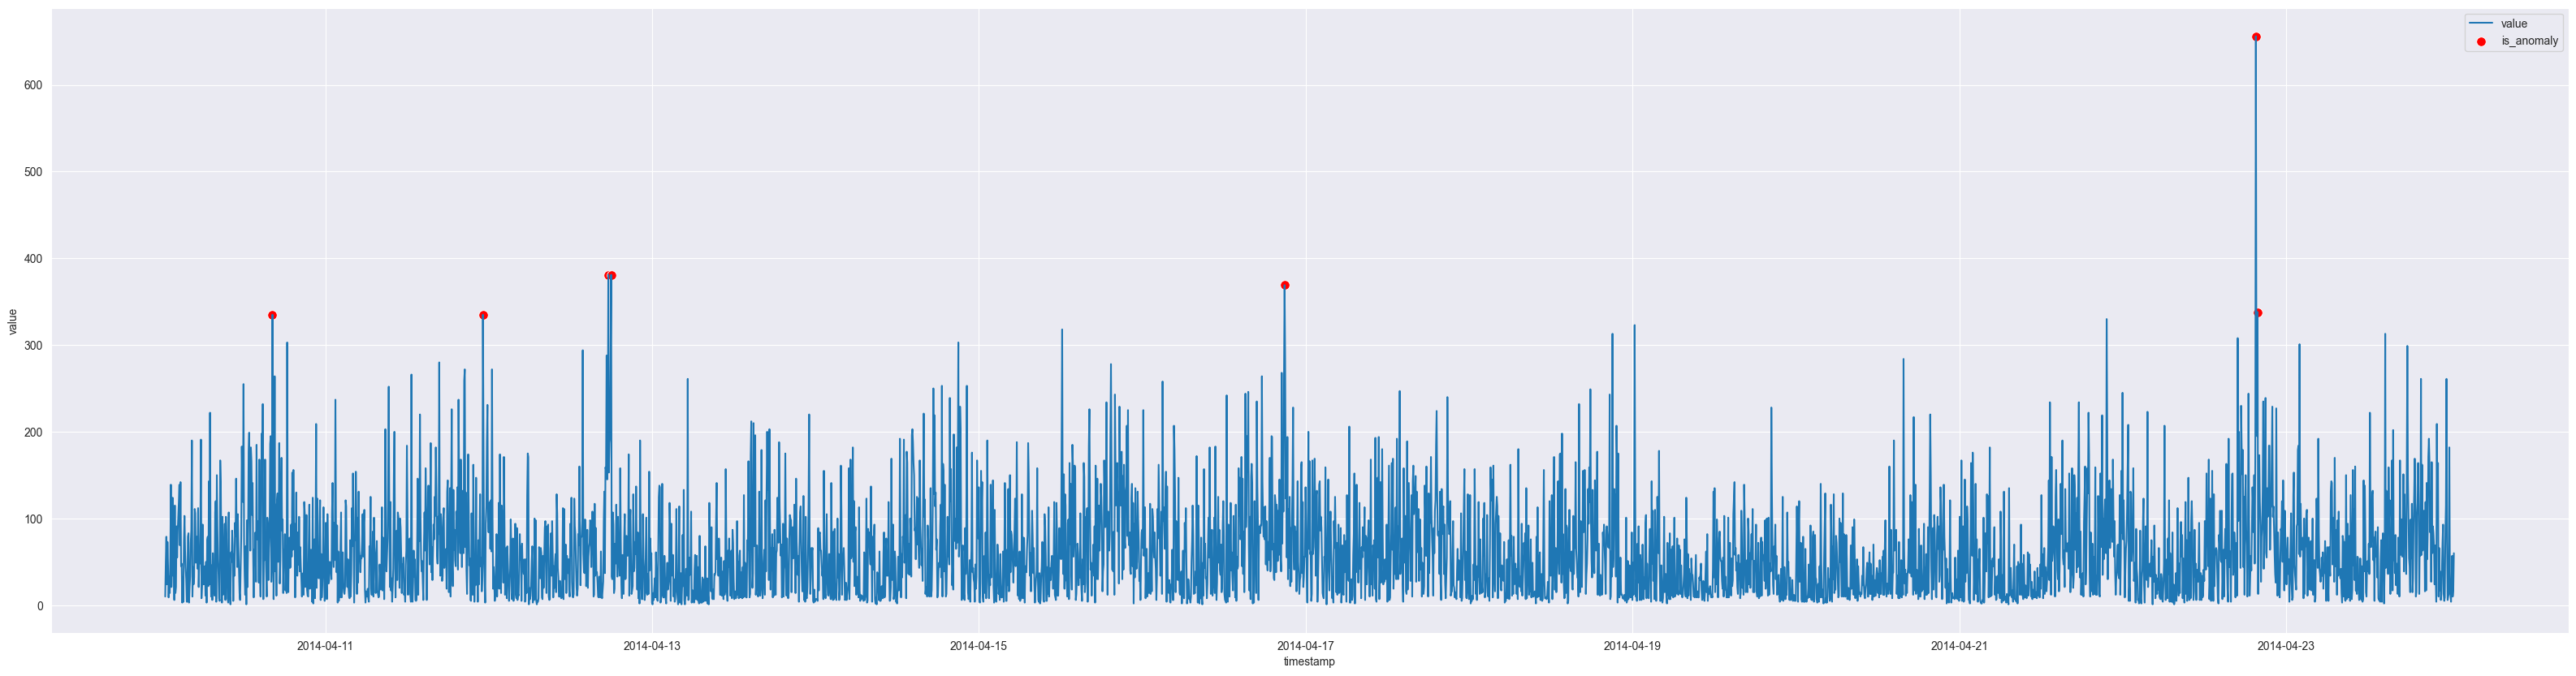

In [67]:
sb.set_style('darkgrid')
plt.figure(figsize=(40,10))
sb.lineplot(data_copy, x='timestamp', y='value', label='value')
sb.scatterplot(data=data_copy[(data_copy['is_anomaly'] == True)], x='timestamp', y='value', color='red', label='is_anomaly', s=70)
plt.legend()